In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [4]:
# Load dataset
data = pd.read_csv("Students Performance .csv")

In [5]:
# Preview data
print("First 5 rows:")
print(data.head())

print("\nShape:")
print(data.shape)

print("\nColumns:")
print(data.columns)

print("\nMissing values:")
print(data.isnull().sum())

print("\nGrade counts:")
print(data["Grade"].value_counts())


First 5 rows:
  Student_ID Student_Age     Sex High_School_Type Scholarship Additional_Work  \
0   STUDENT1       19-22    Male            Other         50%             Yes   
1   STUDENT2       19-22    Male            Other         50%             Yes   
2   STUDENT3       19-22    Male            State         50%              No   
3   STUDENT4          18  Female          Private         50%             Yes   
4   STUDENT5       19-22    Male          Private         50%              No   

  Sports_activity Transportation  Weekly_Study_Hours Attendance Reading Notes  \
0              No        Private                   0     Always     Yes   Yes   
1              No        Private                   0     Always     Yes    No   
2              No        Private                   2      Never      No    No   
3              No            Bus                   2     Always      No   Yes   
4              No            Bus                  12     Always     Yes    No   

  Listening_

In [6]:
# Fill missing value in Scholarship with the most common value
data["Scholarship"] = data["Scholarship"].fillna(data["Scholarship"].mode()[0])

# Create pass/fail target
data["Pass"] = data["Grade"].apply(lambda x: 0 if x == "Fail" else 1)
print(data["Pass"].value_counts())

print("\nPass/Fail counts:")
print(data["Pass"].value_counts())

# Drop ID and original grade column
X = data.drop(columns=["Student_ID", "Grade", "Pass"])
y = data["Pass"]

# Convert categorical columns to numeric
X = pd.get_dummies(X, drop_first=True)

print("\nEncoded feature columns:")
print(X.columns)


Pass
1    137
0      8
Name: count, dtype: int64

Pass/Fail counts:
Pass
1    137
0      8
Name: count, dtype: int64

Encoded feature columns:
Index(['Weekly_Study_Hours', 'Student_Age_19-22', 'Student_Age_23-27',
       'Sex_Male', 'High_School_Type_Private', 'High_School_Type_State',
       'Scholarship_25%', 'Scholarship_50%', 'Scholarship_75%',
       'Additional_Work_Yes', 'Sports_activity_Yes', 'Transportation_Private',
       'Attendance_Always', 'Attendance_Never', 'Attendance_Sometimes',
       'Reading_Yes', 'Notes_No', 'Notes_Yes', 'Listening_in_Class_No',
       'Listening_in_Class_Yes', 'Project_work_Yes'],
      dtype='object')


In [7]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
# Train model
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced",
    max_depth=5
)

model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)

In [9]:
# Make predictions
predictions = model.predict(X_test)

# Evaluate model
print("\nAccuracy:")
print(accuracy_score(y_test, predictions))

print("Error rate:", 1 - accuracy_score(y_test, predictions))

print("\nClassification Report:")
print(classification_report(y_test, predictions, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))
print(data["Pass"].value_counts())


Accuracy:
0.896551724137931
Error rate: 0.10344827586206895

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.50      0.40         2
           1       0.96      0.93      0.94        27

    accuracy                           0.90        29
   macro avg       0.65      0.71      0.67        29
weighted avg       0.92      0.90      0.91        29


Confusion Matrix:
[[ 1  1]
 [ 2 25]]
Pass
1    137
0      8
Name: count, dtype: int64


Sex_Male                    0.501728
High_School_Type_Private    0.230998
Attendance_Always           0.137399
Scholarship_75%             0.080488
Reading_Yes                 0.030571
Transportation_Private      0.018815
Student_Age_19-22           0.000000
Weekly_Study_Hours          0.000000
Student_Age_23-27           0.000000
Scholarship_50%             0.000000
dtype: float64


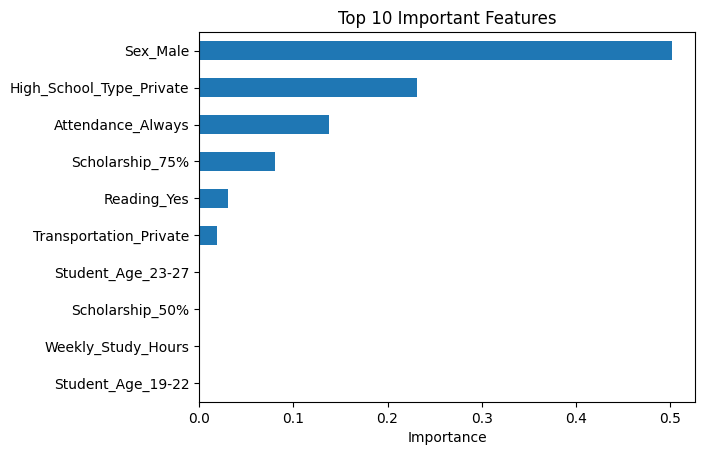

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = feature_importances.sort_values(ascending=False).head(10)

print(top_features)

top_features.sort_values().plot(kind="barh")
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.show()